# Archetypal Analysis (AA) on CD8+ T cells


These notebooks contain the code to annotate the data in our CD8 T cells dataset (the CD8 T cell compartment of the multi-omic scATAC+RNA-seq dataset collected at day 7 post-infection with the Armstrong (acute) or clone 13 (chronic) strains of lymphocytic choriomeningitis virus (LCMV)). 

The RNA matrix for both clones filtered for CD8 T cells (rna_CD8.h5ad), corresponding ATAC matrix (atac_CD8.h5ad)  and peaks-to-genes map (nearest_genes_to_summits.distances.csv) can be downloaded at https://doi.org/10.6084/m9.figshare.31843234

The preprocessed adata_rna and adata_atac_raw anndata objects used for ArchVelo analysis of each clone should be downloaded into the processed_data/arm/ and processed_data/cl13/ folders respectively. 

In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

In [4]:
import scanpy as sc

In [5]:
import ArchVelo as av

In [6]:
data_outdir = 'processed_data/2_clones/'
model_outdir = 'modeling_results/2_clones/'
outdir = model_outdir+'archetypes/'
os.makedirs(outdir, exist_ok = True)

In [7]:
num_comps = 9

In [8]:
import os
fig_outdir = 'figures/2_clones/'
os.makedirs(fig_outdir, exist_ok = True)

# Read in data

In [9]:
# preprocessed ATAC for ArchVelo
atac = sc.read_h5ad('data/2_clones/atac_CD8.h5ad')

In [10]:
adata_rna_arm = sc.read_h5ad('processed_data/arm/adata_rna.h5ad')
adata_rna_cl13 = sc.read_h5ad('processed_data/cl13/adata_rna.h5ad')

In [ ]:
sc.pp.filter_genes(atac, min_cells=0.01*min(adata_rna_arm.shape[0], adata_rna_cl13.shape[0]))

In [ ]:
atac.layers['poisson_corrected'] = np.ceil(atac.layers['raw'].todense()/2)
atac.X = np.array(atac.layers["poisson_corrected"].copy())
sc.experimental.pp.normalize_pearson_residuals(atac, theta=1)
atac.layers["pearson"] = atac.X.copy()

In [ ]:
atac.shape

In [ ]:
peak_annotation = pd.read_csv('data/nearest_genes_to_summits.distances.csv', index_col = [0,1])#.droplevel(0)
peak_annotation = peak_annotation.reset_index().set_index('name')

In [32]:
adata_rna = sc.read_h5ad('processed_data/2_clones/adata_rna.h5ad')

In [ ]:
#only leave genes that map to rna counts
mapped_genes = np.unique(np.unique(peak_annotation['gene'].dropna()))
rna_genes = adata_rna.var_names
shared_genes_total = np.intersect1d(mapped_genes, rna_genes)
rel_peaks_total = atac.var_names[peak_annotation.loc[atac.var_names,:]['gene'].isin(shared_genes_total).values]

In [ ]:
len(rel_peaks_total)

In [ ]:
atac = atac[:, rel_peaks_total]

In [ ]:
atac.shape

In [ ]:
atac.write(data_outdir+'adata_atac_raw_pre.h5ad')

In [10]:
# apply AA

In [11]:
atac = sc.read_h5ad(data_outdir+'adata_atac_raw_pre.h5ad')

In [12]:
atac.shape

(6409, 65447)

In [21]:
np.random.seed(42)

In [33]:
outdir = model_outdir+'archetypes/'
os.makedirs(outdir, exist_ok = True)

In [22]:
XC, S = av.apply_AA_no_test(atac, 
                  k = num_comps,
                  outdir = outdir, 
                  )

Applying AA...
[29646, 10055, 1630, 51054, 50007, 64304, 18499, 48603, 13772]
[29646, 10055, 1630, 51054, 50007, 64304, 18499, 48603, 13772]

Principal Convex Hull Analysis / Archetypal Analysis
A 9 component model will be fitted
To stop algorithm press control C

-----------+------------+------------+-------------+------------+------------+------------+------------+
 Iteration | Expl. var. | Cost func. | Delta SSEf. |        muC |    mualpha |        muS |  Time(s)   
-----------+------------+------------+-------------+------------+------------+------------+------------+
         1 |     0.0002 | 3.8030e+08 | 3.0953e-01 | 1.9349e-01 | 6.1917e+00 | 1.1536e+00 |    70.0000 

         2 |     0.0003 | 3.8027e+08 | 7.8683e-05 | 2.9951e-01 | 3.8338e+01 | 7.1431e+00 |    62.0000 

         3 |     0.0021 | 3.7957e+08 | 1.8348e-03 | 4.6363e-01 | 2.3738e+02 | 4.4228e+01 |    61.0000 

         4 |     0.0032 | 3.7916e+08 | 1.0667e-03 | 2.8706e+00 | 1.4698e+03 | 3.4231e+01 |    52.0000 

     

In [34]:
XC = pd.read_csv(outdir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])
adata_rna.obs[['A_'+str(i) for i in range(num_comps)]] = XC.values

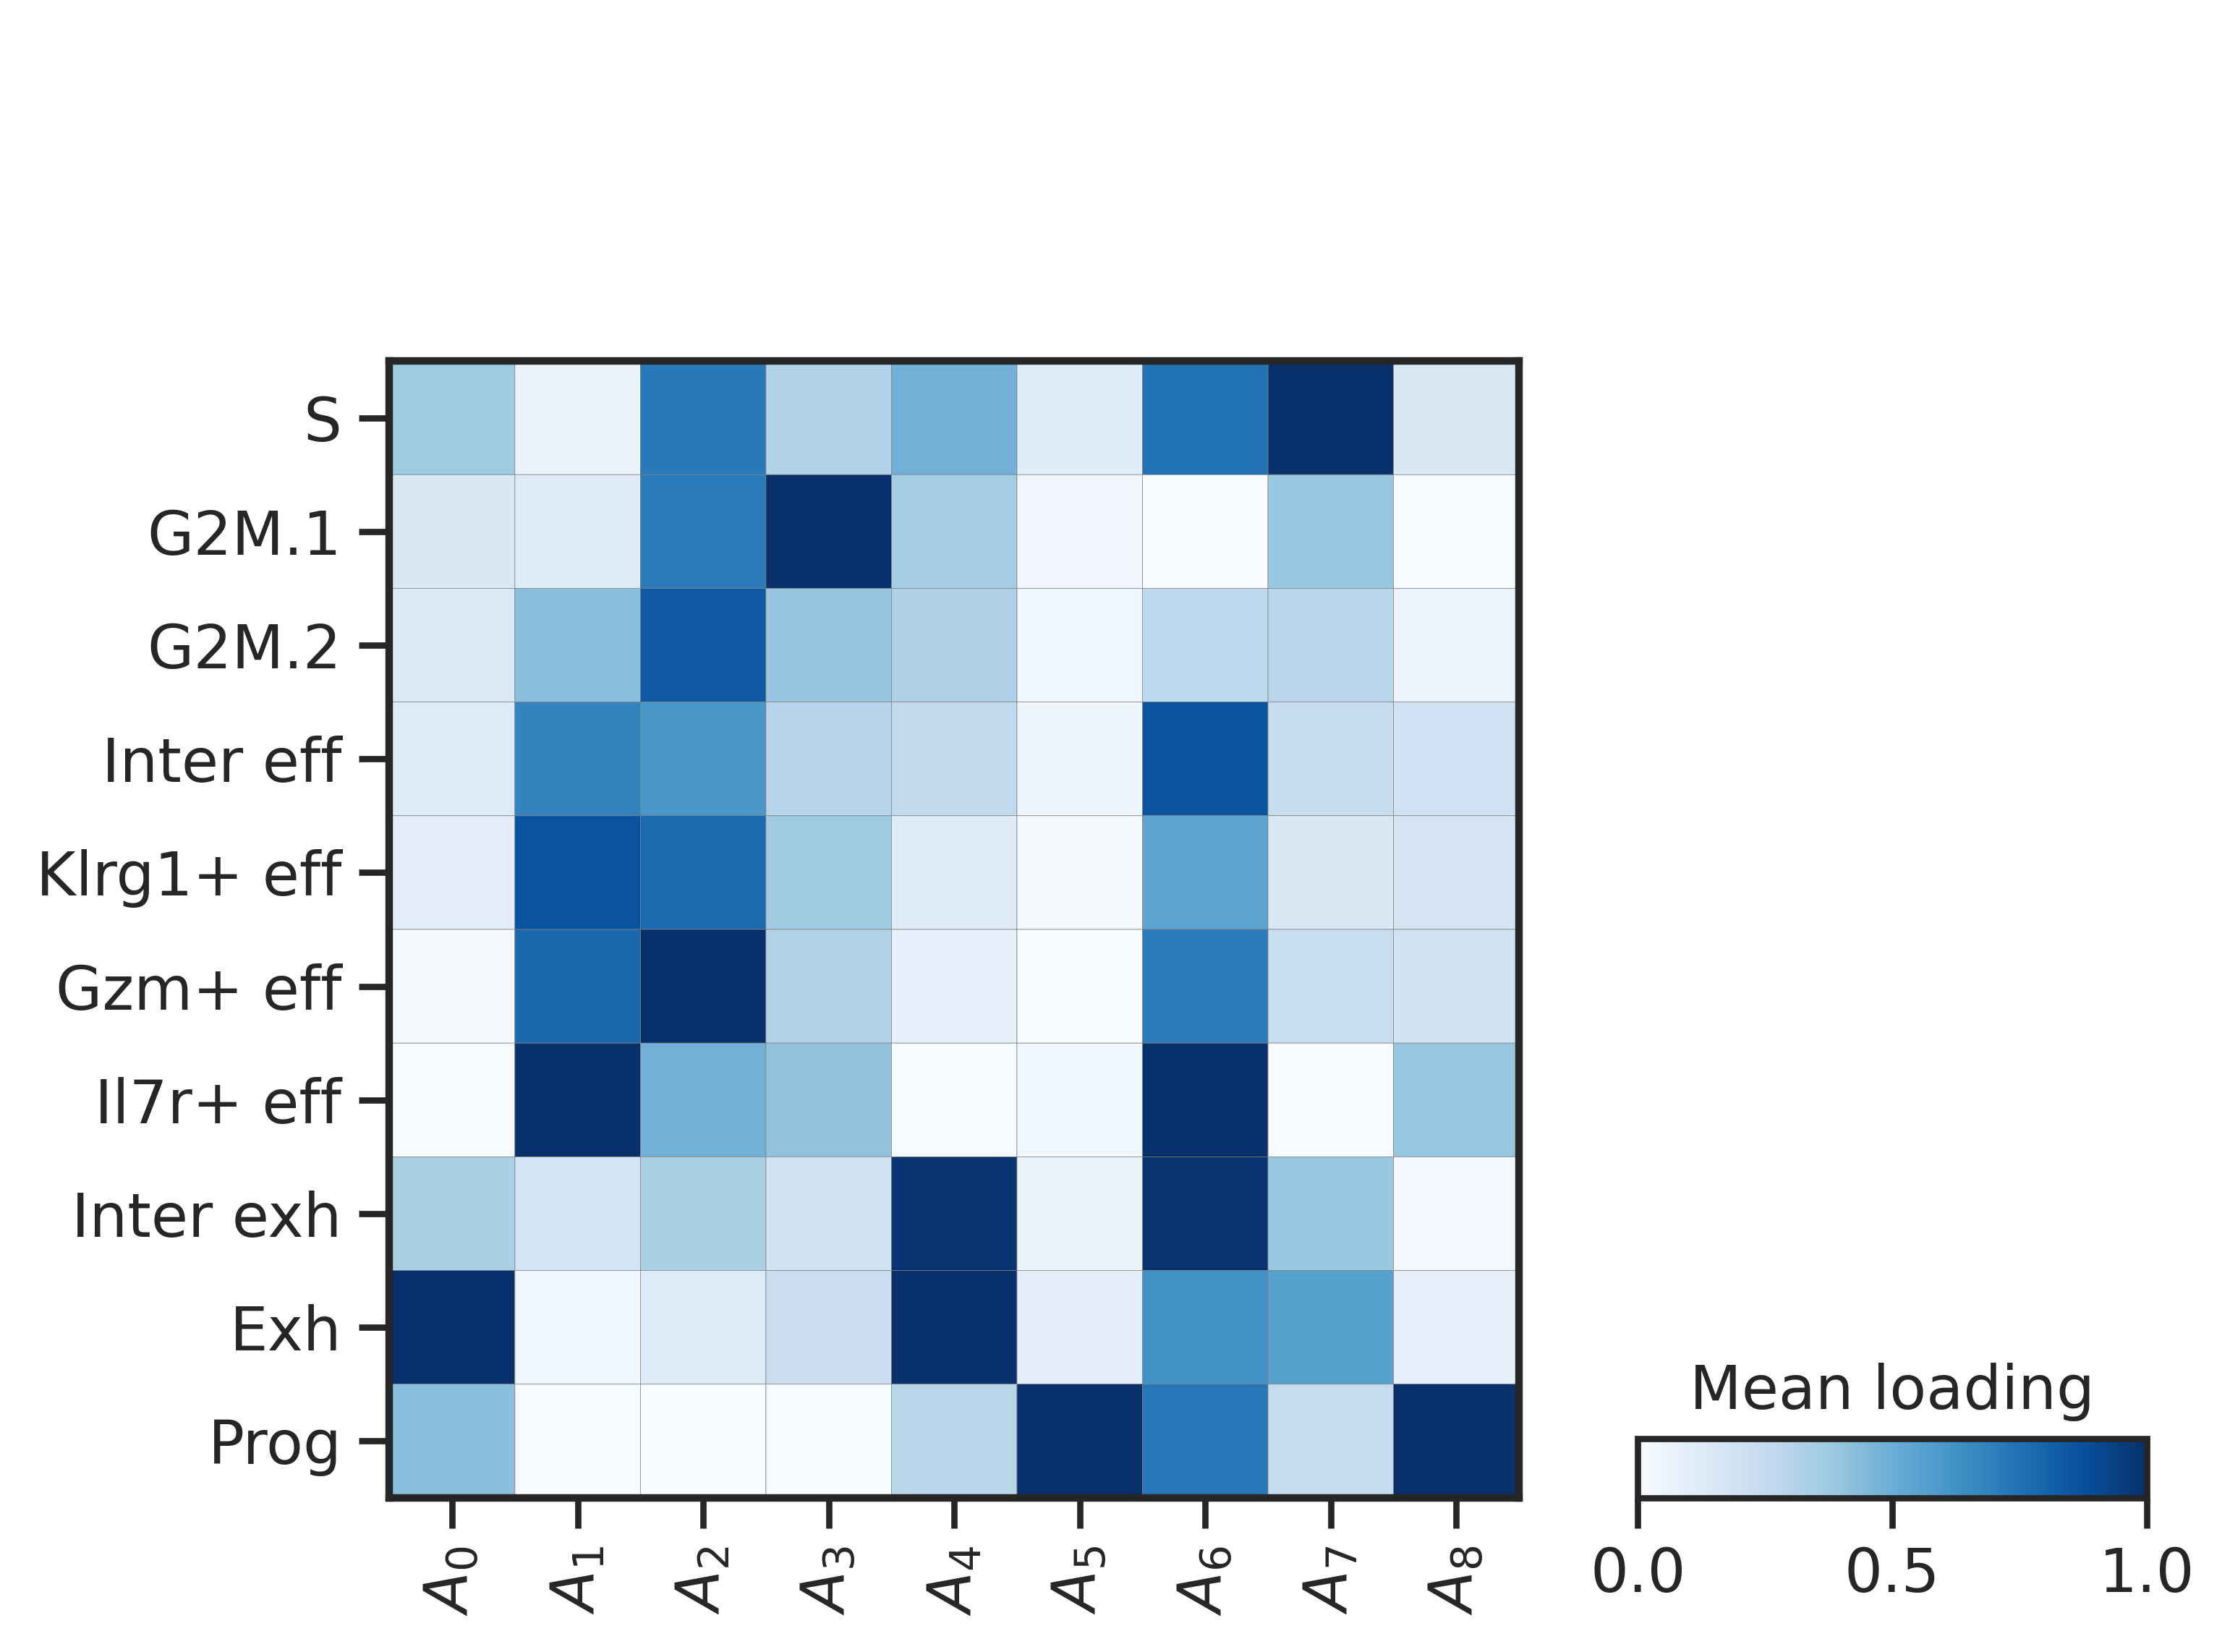

In [35]:
# 9 comps
ct_order = [ 'S', 'G2M.1', 'G2M.2', 'Inter eff', 'Klrg1+ eff', 'Gzm+ eff',  'Il7r+ eff', 'Inter exh', 'Exh','Prog']

sns.set(style = 'ticks', font_scale = 1.2)
fig, ax = plt.subplots(1,1,dpi = 500)
g = sc.pl.matrixplot(adata_rna, ['A_'+str(i) for i in range(num_comps)],
                     groupby = 'coarse', 
                     standard_scale = 'var', 
                     categories_order = ct_order,
                     show = False,
                     cmap = 'Blues', swap_axes = False,
                     ax = ax,
                     colorbar_title = 'Mean loading')
g['mainplot_ax'].set_xticks(np.arange(0,num_comps)+0.5, ['$A_'+str(i)+'$' for i in range(num_comps)])
plt.tight_layout()
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.png', transparent = True,
            dpi = 600)
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.svg', transparent = True,
            dpi = 600)

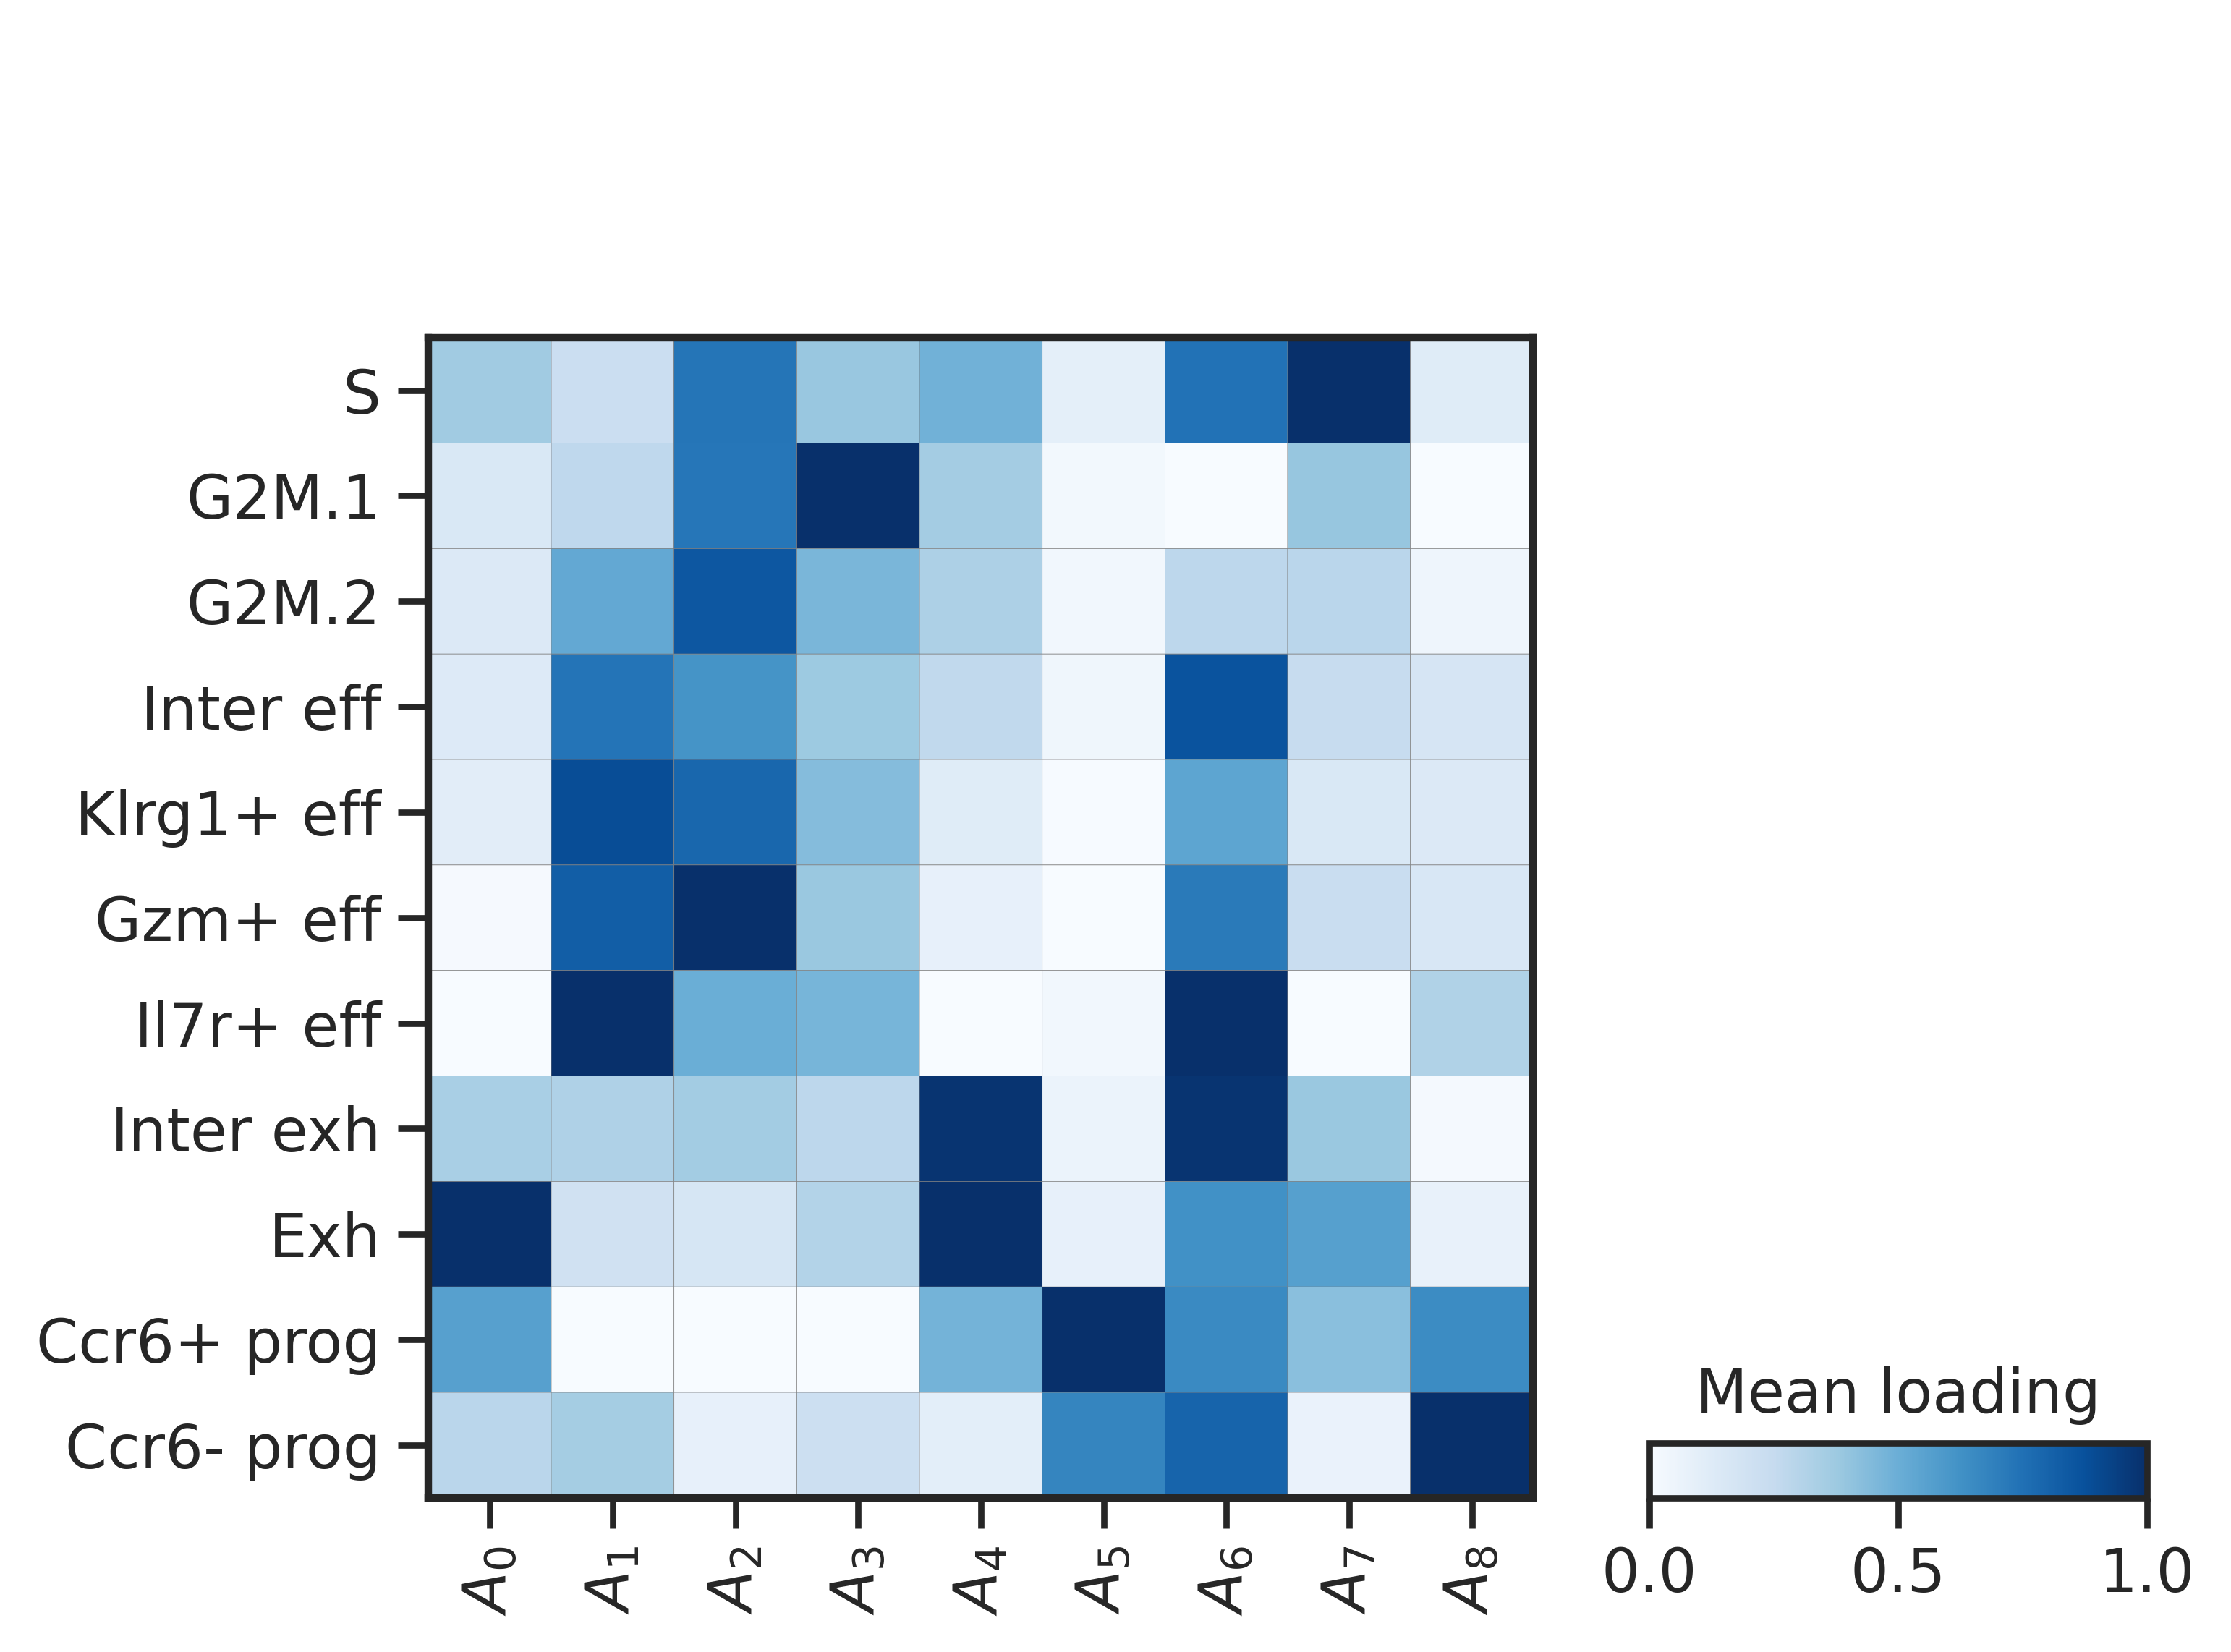

In [36]:
# 9 comps
ct_order = [ 'S', 'G2M.1', 'G2M.2', 'Inter eff', 'Klrg1+ eff', 'Gzm+ eff',  'Il7r+ eff', 'Inter exh', 'Exh','Ccr6+ prog', 'Ccr6- prog']

sns.set(style = 'ticks', font_scale = 1.2)
fig, ax = plt.subplots(1,1,dpi = 500)
g = sc.pl.matrixplot(adata_rna, ['A_'+str(i) for i in range(num_comps)],
                     groupby = 'small_coarse', 
                     standard_scale = 'var', 
                     categories_order = ct_order,
                     #return_fig=True,
                     show = False,
                     #dendrogram = True, 
                     cmap = 'Blues', swap_axes = False,
                     ax = ax,
                     colorbar_title = 'Mean loading')
g['mainplot_ax'].set_xticks(np.arange(0,num_comps)+0.5, ['$A_'+str(i)+'$' for i in range(num_comps)])
plt.tight_layout()
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated_small_coarse.png', transparent = True,
            dpi = 600)
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated_small_coarse.svg', transparent = True,
            dpi = 600)